# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [2]:
# Importe as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:

# leia os conjuntos de dados em DataFrames
df_orders = pd.read_csv("/datasets/instacart_orders.csv", sep=';')
df_products = pd.read_csv("/datasets/products.csv", sep=';')
df_order_products = pd.read_csv("/datasets/order_products.csv", sep=';')
df_aisles = pd.read_csv("/datasets/aisles.csv", sep=';')
df_departments = pd.read_csv("/datasets/departments.csv", sep=';')



In [4]:
# imprima as informações sobre o DataFrame
df_orders.info(show_counts=True)
# coluna "days_since_prior_order" contem valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [5]:
# imprima as informações sobre o DataFrame
df_products.info()
# coluna 'product_name' contém valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [6]:
# imprima as informações sobre o DataFrame
df_order_products.info(show_counts=True)
# coluna 'add_to_cart_order' contém valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [7]:
# imprima as informações sobre o DataFrame
df_aisles.info()
# sem linhas nulas 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [8]:
# imprima as informações sobre o DataFrame
df_departments.info()
# sem linhas nulas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados:


Os datasets foram lidos utilizando o parâmetro `sep=`, para informar ao pandas como ler corretamente os campos, e posteriormente impressos para verificação. 
Após a análise das informações com o método `info()`, foi possível constatar a presença de valores nulos em algumas colunas, indicando a necessidade de tratamento em etapas posteriores. Também foi observado que alguns tipos de dados poderão ser ajustados futuramente, conforme a necessidade da análise exploratória.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução


Escreva aqui seu plano para a Etapa 2. Preparação de dados:


#### Verificação e correção dos tipos de dados

Verificar se há necessidade de alterar os tipos de dados de cada coluna em cada dataset, ajustando-os para tipos mais adequados, como `int`, `category` ou `object`.

#### Identificação e tratamento de valores ausentes

Analisar a presença de valores ausentes em cada dataset e verificar a necessidade de tratamento desses valores.

#### Identificação e remoção de duplicatas

Identificar registros duplicados dentro de cada dataset e removê-los, quando necessário.

#### Verificação final dos dados

Analisar cada etapa realizada no processo de preparação dos dados, a fim de identificar possíveis inconsistências ou erros e corrigi-los posteriormente.


## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [9]:
# Verificar se há pedidos duplicados
print(df_orders.duplicated().sum())
# Verificando a quantidade de duplicatas no dataframe
print()
print(df_orders[df_orders.duplicated()])

15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48        


### Há linhas duplicadas? Se sim, o que elas têm em comum?

Sim, há duplicatas. As duplicatas identifacadas apresentam os mesmos valores nas colunas `order_dow` e `order_hour_of_day` apenas das outras colunas apresentarem valores distintos.


In [10]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

print(df_orders[(df_orders['order_hour_of_day'] == 2) & (df_orders['order_dow'] == 3)])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

### O que esse resultado quer dizer?
O resultado mostra que existem 121 registros de pedidos feitos às 2h da manhã de uma quartas-feiras, provavelmente contendo duplicatas que foram identificadas anteriormente. 

In [11]:
# Remova pedidos duplicados
df_orders = df_orders.drop_duplicates().reset_index(drop=True)
print(df_orders[(df_orders['order_hour_of_day'] == 2) & (df_orders['order_dow'] == 3)])
print()
print('Agora o subset contém apenas 106 linhas ao invés de 121 como mostrado anteriormente.') 

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
456998   3384021    14881             6          3                  2   
458801    910166   164782            18          3                  2   
459620   1680532   106435             6          3                  2   
468309    222962    54979            59          3                  2   
477511   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [12]:
# Verifique as linhas duplicadas mais uma vez



In [13]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(df_orders.duplicated().sum())

0




### Descreva brevemente suas conclusões e o que você fez com elas.

Foi constatado que o registro de pedidos do dataset `instacart_orders.csv` continha duplicatas nos pedidos feitos especificamente às 2h da manhã em quartas-feiras. Após a filtragem do dataset para identificar esses casos, foi aplicado o método `drop_duplicates()` em conjunto com `reset_index(drop=True)` diretamente no DataFrame para remover as duplicatas. Por fim, foi realizada uma nova análise para verificar se ainda havia registros duplicados.

### DataFrame `products`

In [14]:

# Verifique se há linhas completamente duplicadas
print(df_products.duplicated().sum())



0


In [15]:


# Verifique apenas IDs dos produtos duplicados

print(df_products[df_products['product_id'].duplicated()])


Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [16]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
print(df_products['product_name'].dtype)
df_products['product_name'] = df_products['product_name'].str.lower()
df_products[df_products['product_name'].duplicated()]

object


,product_id,product_name,aisle_id,department_id
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
436,437,NaN,100,21
...,...,...,...,...
49689,49690,high performance energy drink,64,7
49690,49691,original pancake & waffle mix,130,14
49691,49692,organic instant oatmeal light maple brown sugar,130,14
49692,49693,spring water body wash,127,11


In [17]:

# Verifique os nomes de produtos duplicados que não estão faltando
print(df_products[(df_products['product_name'].duplicated()) & (df_products['product_name'].notna())])

       product_id                                     product_name  aisle_id  \
2058         2059                                  biotin 1000 mcg        47   
5455         5456                 green tea with ginseng and honey        96   
5558         5559                           cream of mushroom soup        69   
7558         7559                        cinnamon rolls with icing       105   
9037         9038                           american cheese slices        21   
...           ...                                              ...       ...   
49689       49690                    high performance energy drink        64   
49690       49691                    original pancake & waffle mix       130   
49691       49692  organic instant oatmeal light maple brown sugar       130   
49692       49693                           spring water body wash       127   
49693       49694                          burrito- steak & cheese        38   

       department_id  
2058            

### Descreva brevemente suas conclusões e o que você fez com elas.
Após a análise do dataset `products.csv`, foi constatado que não há linhas completamente duplicadas. No entanto, a coluna product_name contém nomes de produtos duplicados. Isso pode indicar que o mesmo produto foi cadastrado mais de uma vez, mas com IDs distintos.


### DataFrame `departments`

In [18]:
# Verifique se há linhas completamente duplicadas
df_departments.duplicated().sum()

0

In [19]:
# Verifique apenas IDs duplicados de departamentos
print(df_departments[df_departments['department_id'].duplicated()])

Empty DataFrame
Columns: [department_id, department]
Index: []


### Descreva brevemente suas conclusões e o que você fez com elas.
O dataset `departments.csv` não apresenta linhas completamente duplicadas nem ids de departamento repetidos. Isso indica que os dados estão bem estruturados e não exigem limpeza relacionada a duplicatas.

### DataFrame `aisles`

In [20]:
# Verifique se há linhas completamente duplicadas
df_aisles.duplicated().sum()

0

In [21]:
# Verifique apenas IDs duplicados de corredores
print(df_aisles[df_aisles['aisle_id'].duplicated()])

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


### Descreva brevemente suas conclusões e o que você fez com elas.
O dataset `aisles.csv` não consta linhas completamente duplicadas e nem ids de corredores repitidos. Dessa forma, não é necessário realizar nenhuma etapa de limpeza relacionada a duplicatas neste conjunto de dados.

### DataFrame `order_products`

In [22]:
# Verifique se há linhas completamente duplicadas
df_order_products.duplicated().sum()

0

In [23]:
# Verifique mais uma vez se há outros casos complicados de duplicados
df_order_products.duplicated(['order_id', 'product_id']).sum()

0

### Descreva brevemente suas conclusões e o que você fez com elas.

Nâo foi encontrada duplicatas no dataset `order_products.csv`levando a conclusão de que não há neciscidade de limpeza relacionada a  duplicatas. Foi feita uma verificação completa em todo o dataset e verificação de duplicatas lógicas nas colunas `order_id` e `product_id`.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [24]:

# Encontre valores ausentes na coluna 'product_name'
print(df_products[df_products['product_name'].isna()].sample(10))

       product_id product_name  aisle_id  department_id
18471       18472          NaN       100             21
2864         2865          NaN       100             21
48670       48671          NaN       100             21
27449       27450          NaN       100             21
29401       29402          NaN       100             21
47774       47775          NaN       100             21
9864         9865          NaN       100             21
35917       35918          NaN       100             21
7923         7924          NaN       100             21
38306       38307          NaN       100             21


### Descreva brevemente suas conclusões.
Foram encontrados 1.258 valores ausentes na coluna `product_name` do dataframe `df_products`. No entanto, após o uso do método `.sample()`, observou-se que os produtos cujos nomes estão ausentes apresentam os mesmos IDs de departamento (`department_id`) e os mesmos IDs de categoria de corredor do supermercado (`aisle_id`).

In [25]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100
print(df_products[df_products['aisle_id'] == 100].sample(10)) # coletando linhas aleatórias cujo o aisle_id seja igual a 100 para uma análise primária sobre associação  entre ausencia de dados e o número do corredor
print()
df_products[df_products['aisle_id'] == 100].info() # utilizando o método info para ter a confirmação


       product_id product_name  aisle_id  department_id
49237       49238          NaN       100             21
30669       30670          NaN       100             21
15560       15561          NaN       100             21
13785       13786          NaN       100             21
42164       42165          NaN       100             21
48864       48865          NaN       100             21
29363       29364          NaN       100             21
40956       40957          NaN       100             21
41951       41952          NaN       100             21
9953         9954          NaN       100             21

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1258 entries, 37 to 49668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1258 non-null   int64 
 1   product_name   0 non-null      object
 2   aisle_id       1258 non-null   int64 
 3   department_id  1258 non-null   int64 
dtypes: int64(3),

### Descreva brevemente suas conclusões.
Após a análise dos dados utilizando os métodos .sample() e .info(), verificou-se que todos os registros associados ao corredor de ID 100 apresentam valores ausentes na coluna product_name. Da mesma forma, todos os valores ausentes dessa coluna estão concentrados nesse corredor. Isso indica uma associação estrutural entre o corredor 100 e a ausência de nomes de produtos.

In [26]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
print(df_products[df_products['department_id'] == 21].sample(10))
print()
df_products[df_products['department_id'] == 21].info()

       product_id product_name  aisle_id  department_id
26924       26925          NaN       100             21
47335       47336          NaN       100             21
49422       49423          NaN       100             21
11390       11391          NaN       100             21
28196       28197          NaN       100             21
45038       45039          NaN       100             21
16285       16286          NaN       100             21
45999       46000          NaN       100             21
7002         7003          NaN       100             21
22192       22193          NaN       100             21

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1258 entries, 37 to 49668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1258 non-null   int64 
 1   product_name   0 non-null      object
 2   aisle_id       1258 non-null   int64 
 3   department_id  1258 non-null   int64 
dtypes: int64(3),

Após a análise utilizando os mesmos métodos (`.sample()` e `.info()`), observou-se que todos os produtos associados ao department_id igual a 21 apresentam valores ausentes na coluna `product_name`. Isso mostra que os dados ausentes não estão distribuídos de forma aleatória, mas concentrados em um grupo específico, indicando um padrão no dataset.

In [27]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
products_filtered = df_products.query('department_id == 21 & aisle_id == 100') 
print(products_filtered.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1258 entries, 37 to 49668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1258 non-null   int64 
 1   product_name   0 non-null      object
 2   aisle_id       1258 non-null   int64 
 3   department_id  1258 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 49.1+ KB
None


### Descreva brevemente suas conclusões.
Foram encontrados 1258 produtos no corredor com ID 100 e no departamento com ID 21. Todos esses registros estão com o nome do produto ausente (`product_name` nulo).

In [28]:
# Preencha nomes de produtos ausentes com 'Unknown'
mask = (df_products['department_id'] == 21) & (df_products['aisle_id'] == 100) 
df_products.loc[mask, 'product_name'] = df_products.loc[mask, 'product_name'].fillna('Unknown')

print(df_products[(df_products['department_id'] ==21) & (df_products['aisle_id'] == 100)].sample(10))
print()
print(df_products[(df_products['department_id'] ==21) & (df_products['aisle_id'] == 100)].info())

       product_id product_name  aisle_id  department_id
28031       28032      Unknown       100             21
44821       44822      Unknown       100             21
28963       28964      Unknown       100             21
32553       32554      Unknown       100             21
45398       45399      Unknown       100             21
47046       47047      Unknown       100             21
29708       29709      Unknown       100             21
10827       10828      Unknown       100             21
36524       36525      Unknown       100             21
22518       22519      Unknown       100             21

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1258 entries, 37 to 49668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1258 non-null   int64 
 1   product_name   1258 non-null   object
 2   aisle_id       1258 non-null   int64 
 3   department_id  1258 non-null   int64 
dtypes: int64(3),

### Descreva brevemente suas conclusões e o que você fez com elas.
Foram identificados 1258 produtos no corredor de ID 100 e no departamento de ID 21 com nomes ausentes. Após a filtragem com `.query()`, os valores nulos da coluna `product_name` foram preenchidos com 'Unknown' utilizando `.fillna()`. Em seguida, foi feita uma verificação com `.sample()` e confirmada a ausência de dados nulos por meio de `.info()`.

### DataFrame `orders`

In [29]:
# Encontre os valores ausentes
print(df_orders.info())
print()
print(df_orders[df_orders['days_since_prior_order'].isna()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478952 entries, 0 to 478951
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286           

In [30]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
print(df_orders[df_orders['order_number'] == 1])
print()
df_orders[df_orders['order_number'] == 1].info()


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478880   2589657   205028             1          0                 16   
478881   2222353   141211             1          2                 13   
478907   2272807   204154             1          1                 15   
478911   2499542    68810             1          4                 19   
478930   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

### Descreva brevemente suas conclusões e o que você fez com elas.
Foram filtrados os pedidos com order_number igual a 1, correspondendo aos primeiros pedidos de cada cliente. Observou-se que todos esses registros apresentavam valores ausentes na coluna `days_since_prior_order`. Após a substituição, foi utilizada a função `.sample()` para visualizar exemplos aleatórios e, por fim, o método `.info()` confirmou que a coluna estava completamente preenchida com valores nulos, como esperado para primeiros pedidos.

### DataFrame `order_products`

In [31]:

# Encontre os valores ausentes
df_order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [32]:
# Quais são os valores mínimo e máximo dessa coluna?
print(df_order_products['add_to_cart_order'].min())
print(df_order_products['add_to_cart_order'].max())

1.0
64.0


### Descreva brevemente suas conclusões.
Foi realizada a verificação de valores ausentes na coluna `add_to_cart_order` da tabela `df_order_products`, identificando 836 registros nulos. Em seguida, foram utilizados os métodos `.min()` e `.max()` para determinar os valores mínimo e máximo dessa coluna, desconsiderando os valores ausentes. 

In [33]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
order_filtered_null = df_order_products[df_order_products['add_to_cart_order'].isna()]
orders_id_null =  order_filtered_null['order_id']
print(orders_id_null)
print()
print(orders_id_null.count())

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64

836


In [34]:

# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
products_id_null = order_filtered_null['product_id'].nunique()
print(f"Todos os pedidos com valores ausente contém {products_id_null} produtos")
# Agrupe os pedidos com dados ausentes por ID de pedido
order_product_null = order_filtered_null.groupby('order_id')['product_id'].count()
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
order_product_null.min()


Todos os pedidos com valores ausente contém 720 produtos


1

### Descreva brevemente suas conclusões.
Foram identificados 836 pedidos com valores ausentes na coluna add_to_cart_order. Esses pedidos foram agrupados por order_id e analisados quanto à quantidade de produtos. Verificou-se que o menor número de produtos em um único pedido foi 1, indicando que nem todos os pedidos com valores ausentes contêm mais de 64 produtos.

In [35]:


# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
df_order_products["add_to_cart_order"] = df_order_products["add_to_cart_order"].fillna(999)
df_order_products.isna().sum()
df_order_products["add_to_cart_order"] = df_order_products["add_to_cart_order"].astype(int)
print(df_order_products["add_to_cart_order"].dtype)


int64


### Descreva brevemente suas conclusões e o que você fez com elas.
Os valores ausentes foram substituídos por 999 com o método fillna(), e a coluna add_to_cart_order foi convertida para o tipo inteiro utilizando astype(int), para futuras análises.

## Conclusões

Na preparação dos dados, foram verificadas e corrigidas inconsistências para garantir que o conjunto estivesse pronto para análise. Primeiro, conferimos os tipos de dados e ajustamos quando necessário, para que cada coluna tivesse o formato adequado. Em seguida, identificamos valores ausentes e duplicados: os ausentes foram tratados com preenchimento ou substituição, dependendo do contexto, e os duplicados foram removidos para evitar distorções nos resultados.

Essas escolhas foram feitas porque valores ausentes e duplicados podem comprometer a qualidade das análises, gerando interpretações incorretas. O preenchimento com valores padrão ou a remoção foi adotado de acordo com o significado dos dados e com o objetivo de manter consistência.

Em resumo, a etapa garantiu que os dados estivessem limpos, estruturados e confiáveis, permitindo que análises futuras sejam realizadas com maior precisão e sem riscos de vieses causados por problemas de qualidade.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Duplicados e ausentes de todos os dfs foram investigados e corrigidos conforme o roteiro proposto
</div>



# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [36]:
print(df_orders['order_hour_of_day'].min())
print(df_orders['order_hour_of_day'].max())

0
23


In [37]:
print(df_orders['order_dow'].min())
print(df_orders['order_dow'].max())

0
6



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Valores das colunas de dias e horas validados adequadamente.
</div>



### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

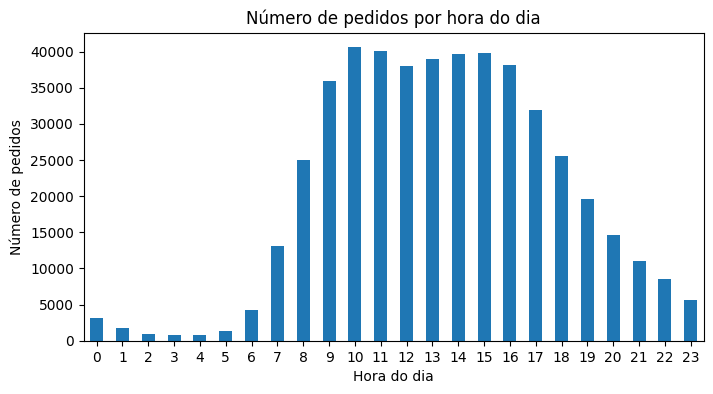

In [38]:

orders_hour = df_orders['order_hour_of_day'].value_counts().sort_index()

# Criar o gráfico
plt.figure(figsize=(8, 4))
orders_hour.plot(kind='bar')
plt.title("Número de pedidos por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=0)
plt.show()



Como podemos ver, os horários com maiores volumes de compra são entre as 10 AM até as 5 PM.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

Departamentos:
    department_id       department
0               1           frozen
1               2            other
2               3           bakery
3               4          produce
4               5          alcohol
5               6    international
6               7        beverages
7               8             pets
8               9  dry goods pasta
9              10             bulk
10             11    personal care
11             12     meat seafood
12             13           pantry
13             14        breakfast
14             15     canned goods
15             16       dairy eggs
16             17        household
17             18           babies
18             19           snacks
19             20             deli
20             21          missing



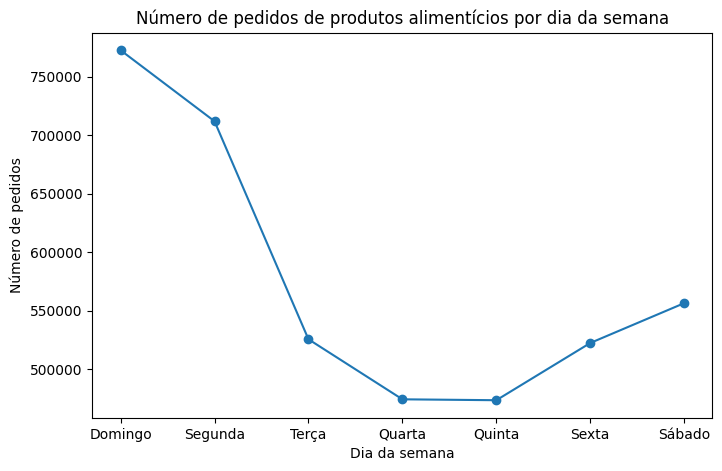

In [39]:

days_map = { 0: 'Domingo', 1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado'} # para renomear os dias da semana ao invés de 0 até 6
print("Departamentos:")
print(df_departments)
print()
food_department = [3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 18, 19, 20]
products_food = df_products[df_products['department_id'].isin(food_department)]

products_food = df_order_products[df_order_products['product_id'].isin(products_food['product_id'])]

order_with_day = products_food.merge(df_orders[['order_id', 'order_dow']], on='order_id')

order_food_day = order_with_day['order_dow'].value_counts().sort_index()
order_food_day.index = order_food_day.index.map(days_map)


plt.figure(figsize=(8,5))
order_food_day.plot(style='o-')
plt.title("Número de pedidos de produtos alimentícios por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Número de pedidos")
plt.show()



A compra de produtos alimentícios ocorre majoritáriamente no Domingo e na seguna como mostra o gráfico acima.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

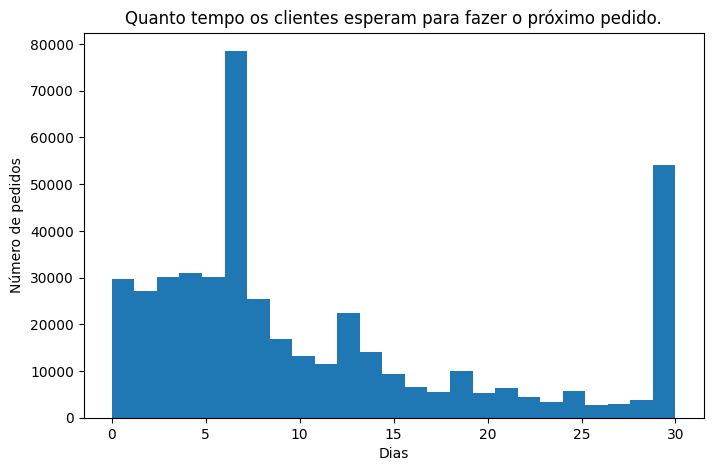

In [40]:


df_orders['days_since_prior_order'].value_counts().sort_index()

plt.figure(figsize=(8,5))
df_orders['days_since_prior_order'].plot(kind='hist', bins=25)
plt.title("Quanto tempo os clientes esperam para fazer o próximo pedido.")
plt.xlabel("Dias")
plt.ylabel("Número de pedidos")
plt.show()


Após analisar o gráifco, podemos constatar que as pessoas costumam demorar, na sua maioria entre 6 à 7 dias tendo um segundo pico de 30 dias.

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

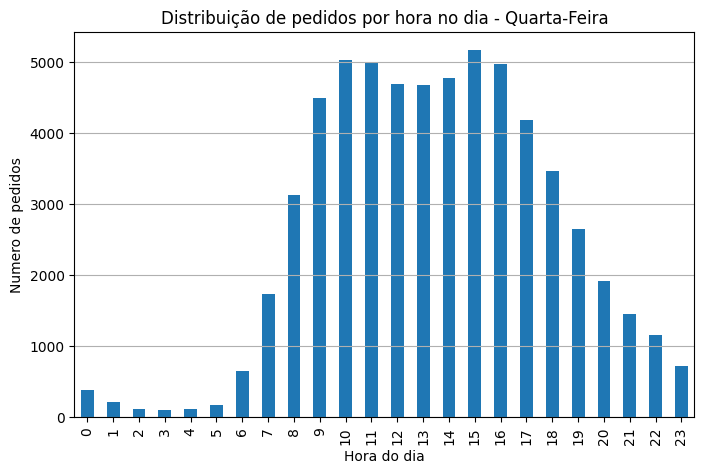

In [41]:
wednesday = df_orders[df_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(8,5))
wednesday.plot(kind='bar')

plt.title("Distribuição de pedidos por hora no dia - Quarta-Feira")
plt.xlabel("Hora do dia")
plt.ylabel("Numero de pedidos")

plt.xticks(range(0,24))
plt.grid(axis='y')
plt.show()

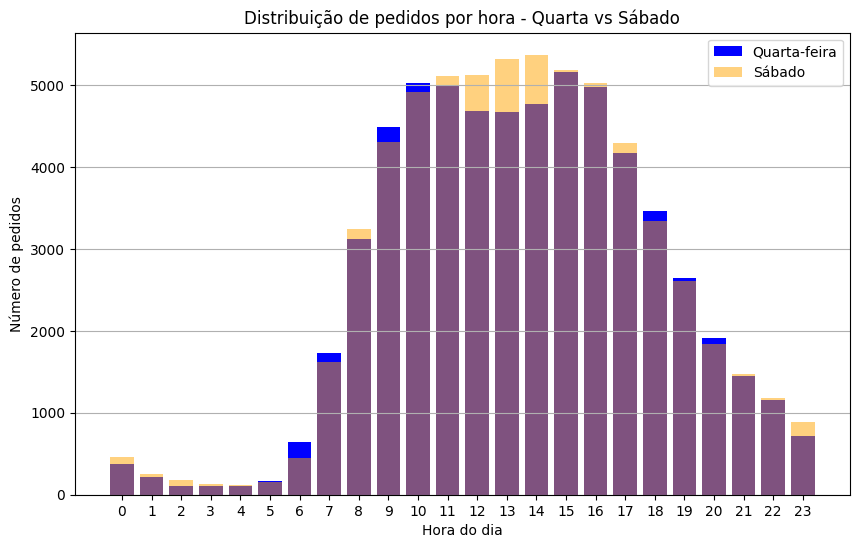

In [49]:

wednesday = df_orders[df_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
saturday = df_orders[df_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(wednesday.index, wednesday.values, color='blue', alpha= 1, label='Quarta-feira')
plt.bar(saturday.index, saturday.values, color='orange', alpha=0.5, label='Sábado')

plt.title("Distribuição de pedidos por hora - Quarta vs Sábado")
plt.xlabel("Hora do dia")
plt.ylabel("Número de pedidos")
plt.xticks(range(0,24))
plt.legend()
plt.grid(axis='y')
plt.show()



Após a análise dos gráficos, observamos que tanto nas quartas-feiras quanto nos sábados os pedidos se concentram entre o final da manhã e o início da tarde, especialmente entre 10h e 15h. Mas, aos sábados há uma leve intensificação no volume de pedidos durante esse intervalo, o que pode indicar maior disponibilidade dos clientes para realizar compras nesse dia.

### [B2] Qual é a distribuição do número de pedidos por cliente?

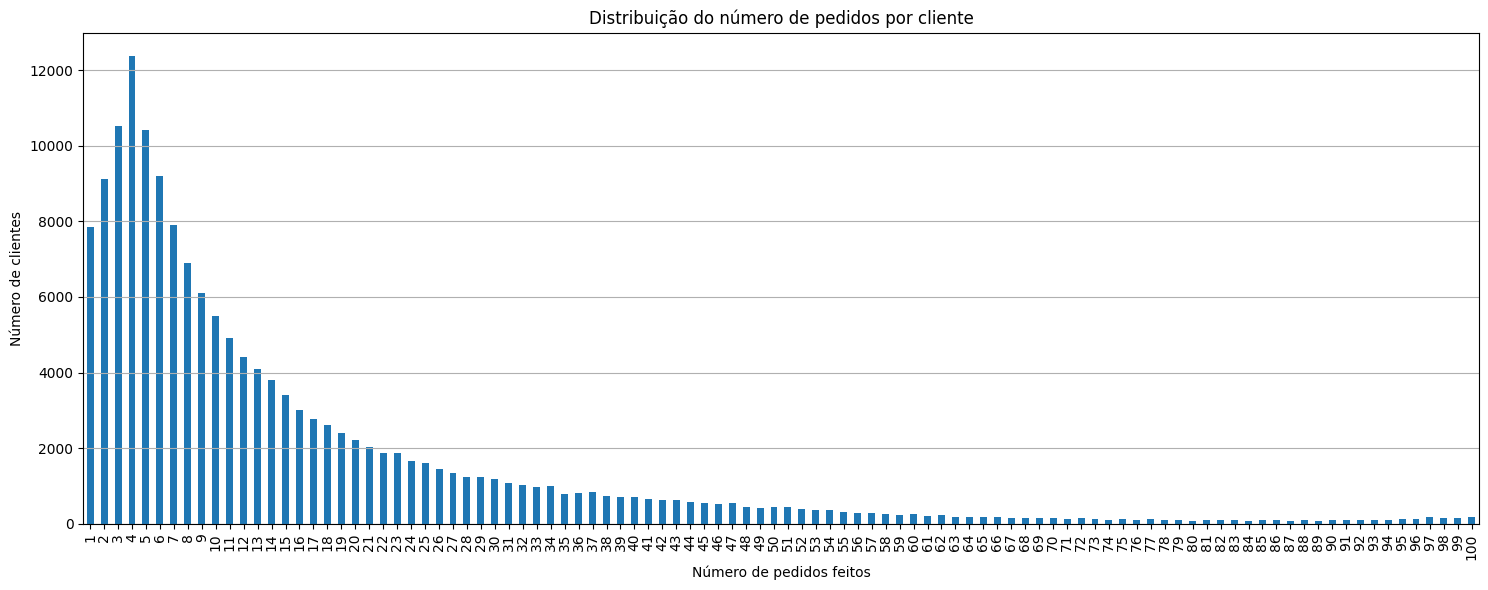

In [43]:
orders_per_customer = df_orders.groupby('user_id')['order_number'].max()
orders_distribution = orders_per_customer.value_counts().sort_index()
plt.figure(figsize=(15,6)) 
ax = orders_distribution.plot(kind='bar')
plt.title("Distribuição do número de pedidos por cliente")
plt.xlabel("Número de pedidos feitos")
plt.ylabel("Número de clientes")
plt.grid(axis='y') 
plt.tight_layout()
plt.show()


Após análise do gráfico, podemos concluir que as maioria dos clientes fazem entre 1 à 9 pedidos, sendo 4 pedidos o volume mais comum.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [144]:
product_counts = df_order_products['product_id'].value_counts().head(20)

In [145]:
top_products = df_products[df_products['product_id'].isin(product_counts.index)] 
top_products = top_products.set_index('product_id').loc[product_counts.index] 
top_products['order_count'] = product_counts.values
top_products = top_products.sort_values(by='order_count', ascending=False)

In [146]:
print(top_products[['order_count', 'product_name']])

       order_count              product_name
24852        66050                    banana
13176        53297    bag of organic bananas
21137        37039      organic strawberries
21903        33971      organic baby spinach
47209        29773      organic hass avocado
47766        24689           organic avocado
47626        21495               large lemon
16797        20018              strawberries
26209        19690                     limes
27845        19600        organic whole milk
27966        19197       organic raspberries
22935        15898      organic yellow onion
24964        15292            organic garlic
45007        14584          organic zucchini
39275        13879       organic blueberries
49683        13675            cucumber kirby
28204        12544        organic fuji apple
5876         12232             organic lemon
8277         11993  apple honeycrisp organic
40706        11781    organic grape tomatoes


  A análise mostra que os produtos mais comprados são principalmente frutas e vegetais frescos, com destaque para banana e bag of organic bananas, que lideram a lista. Além disso, há forte presença de itens orgânicos como morangos, espinafre, abacate e leite integral orgânico.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


###[C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

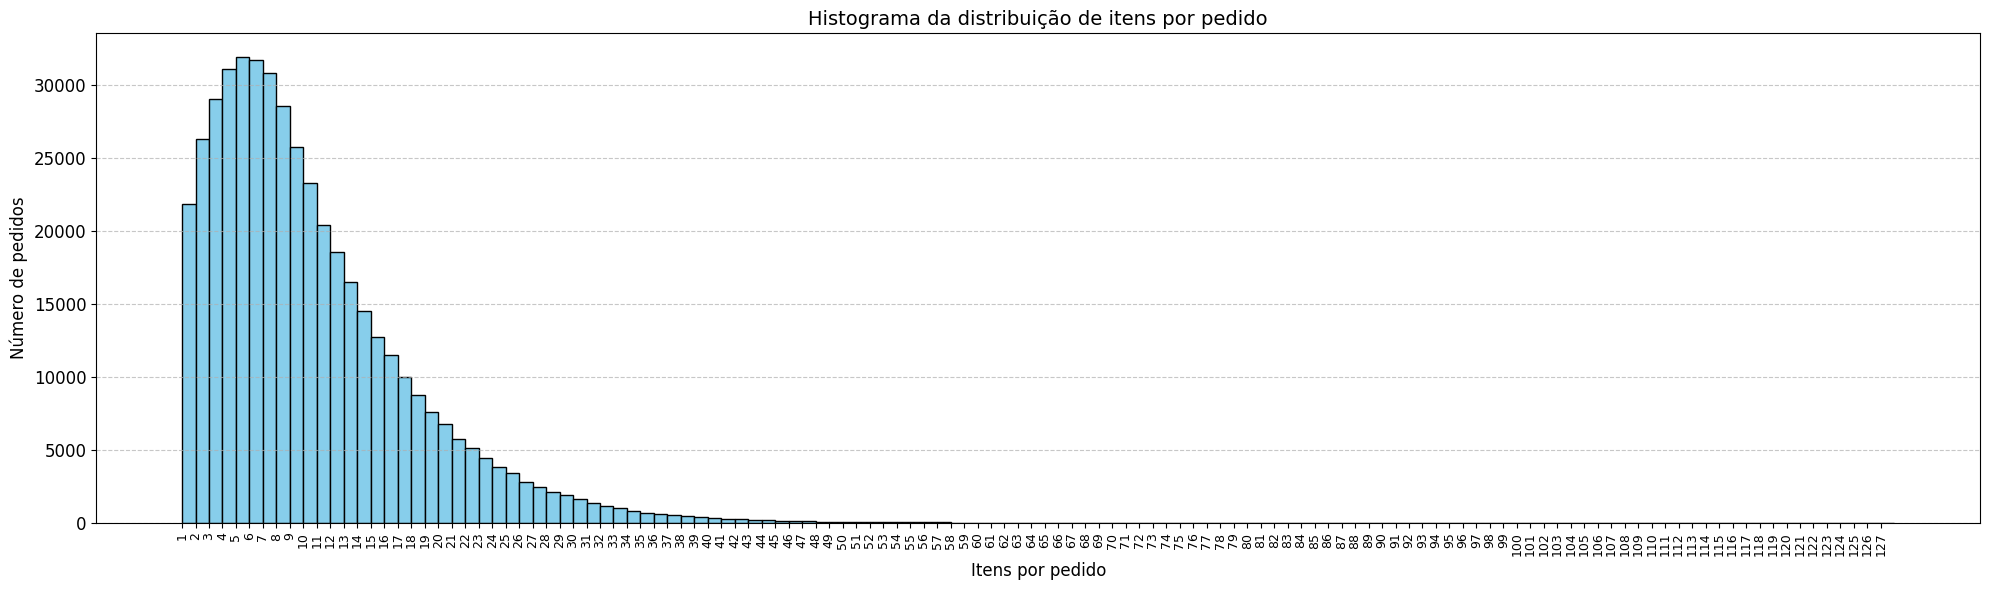

In [74]:
items_per_order = df_order_products.groupby("order_id")["product_id"].count()

plt.figure(figsize=(20,6))
plt.hist(items_per_order, bins=range(1, items_per_order.max()+2), 
         edgecolor="black", color="skyblue")

plt.xlabel("Itens por pedido", fontsize=12)
plt.ylabel("Número de pedidos", fontsize=12)
plt.title("Histograma da distribuição de itens por pedido", fontsize=14)

plt.xticks(range(1, items_per_order.max()+1), rotation=90, fontsize=9)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


Normalmente os pedidos têm em média 3 itens, e a distribuição mostra que a maioria dos pedidos fica entre 1 e 4 itens. Isso significa que os clientes costumam comprar poucos produtos por vez, com raros pedidos maiores.


### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [148]:

df_merged = df_order_products.merge(df_products, on="product_id")
df_reordered = df_merged[df_merged["reordered"] == 1]
top20 = (
    df_reordered.groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

print(top20)


       product_id              product_name  count
18104       24852                    banana  55763
9528        13176    bag of organic bananas  44450
15368       21137      organic strawberries  28639
15936       21903      organic baby spinach  26233
34407       47209      organic hass avocado  23629
34828       47766           organic avocado  18743
20285       27845        organic whole milk  16251
34725       47626               large lemon  15044
20375       27966       organic raspberries  14748
12193       16797              strawberries  13945
19088       26209                     limes  13327
16700       22935      organic yellow onion  11145
18186       24964            organic garlic  10411
32792       45007          organic zucchini  10076
36219       49683            cucumber kirby   9538
20543       28204        organic fuji apple   8989
5978         8277  apple honeycrisp organic   8836
28607       39275       organic blueberries   8799
4267         5876             o

A análise dos dados mostra que os 20 principais itens em pedidos repetidos são aqueles que possuem maior frequência de recompra, ou seja, produtos que os clientes adicionam novamente ao carrinho em diferentes pedidos.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [149]:

df_merged = df_order_products.merge(df_products, on="product_id")
total_orders = df_merged.groupby(["product_id", "product_name"]).size().reset_index(name="total")
reordered_orders = df_merged[df_merged["reordered"] == 1].groupby(["product_id", "product_name"]).size().reset_index(name="reordered")
df_ratio = total_orders.merge(reordered_orders, on=["product_id", "product_name"], how="left").fillna(0)
df_ratio["ratio_reordered"] = df_ratio["reordered"] / df_ratio["total"]

print(df_ratio[["product_id", "product_name", "ratio_reordered"]].sort_values("ratio_reordered", ascending=False))


       product_id                                       product_name  \
13453       14721                            bone strength take care   
19195       20949                           vanilla sandwich cookies   
6136         6723                                   palmiers- petite   
6144         6732                  naturally sparkling mineral water   
41319       45088  california dill pollen & garlic goat cheese & ...   
...           ...                                                ...   
9559        10485                                  caramel apple pop   
34562       37690  calypso fresh 2x concentrated scentsations 166...   
9558        10484                                 avocado and greens   
9548        10474                       nustevia white stevia powder   
39401       42984  salsa for all seasons half guacamole half roas...   

       ratio_reordered  
13453              1.0  
19195              1.0  
6136               1.0  
6144               1.0  
41319     

Essa análise mostra quais produtos têm maior tendência de recompra. Produtos com proporção próxima de 1.0 são quase sempre repetidos.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [150]:

df_orders_products = df_order_products.merge(df_orders, on="order_id")
total_by_user = df_orders_products.groupby("user_id").size().reset_index(name="total")
reordered_by_user = (
    df_orders_products[df_orders_products["reordered"] == 1]
    .groupby("user_id")
    .size()
    .reset_index(name="reordered")
)

df_user_ratio = total_by_user.merge(reordered_by_user, on="user_id", how="left").fillna(0)
df_user_ratio["ratio_reordered"] = df_user_ratio["reordered"] / df_user_ratio["total"]

print(df_user_ratio[["user_id", "ratio_reordered"]].sort_values("ratio_reordered", ascending=False))


        user_id  ratio_reordered
99672    137587              1.0
125732   173474              1.0
10138     13918              1.0
45067     62300              1.0
45074     62307              1.0
...         ...              ...
138474   190953              0.0
86539    119371              0.0
45695     63173              0.0
45689     63163              0.0
120146   165726              0.0

[149626 rows x 2 columns]


A proporção de pedidos repetidos varia de cliente para cliente. Alguns têm valores altos, mostrando que compram quase sempre os mesmos produtos, enquanto outros apresentam valores baixos, indicando maior diversidade nas compras.


### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [151]:

df_first = df_order_products[df_order_products["add_to_cart_order"] == 1]
top20_first = (
    df_first.merge(df_products, on="product_id")
    .groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)
print(top20_first)


       product_id                 product_name  count
13414       24852                       banana  15562
7127        13176       bag of organic bananas  11026
15028       27845           organic whole milk   4363
11384       21137         organic strawberries   3946
25439       47209         organic hass avocado   3390
11786       21903         organic baby spinach   3336
25732       47766              organic avocado   3044
10622       19660                 spring water   2336
9050        16797                 strawberries   2308
15102       27966          organic raspberries   2024
24024       44632   sparkling water grapefruit   1914
26519       49235          organic half & half   1797
25658       47626                  large lemon   1737
115           196                         soda   1733
20853       38689     organic reduced fat milk   1397
14158       26209                        limes   1370
6660        12341                hass avocados   1340
3153         5785  organic r

Os resultados mostram quais produtos os clientes tendem a colocar primeiro no carrinho, indicando itens considerados essenciais ou prioritários na compra. 


# Conclusão geral do projeto:

#### Principais Descobertas:
1. Dias da semana:
os pedidos concentram-se em determinados dias, com destaque para padrões recorrentes em horários específicos (como pedidos às 2h da manhã em quartas-feiras), revelando hábitos consistentes de compra.

2. Tempo entre pedidos: 
a coluna days_since_prior_order mostrou tanto valores regulares (clientes com ciclos de recompra previsíveis) quanto valores ausentes, indicando a necessidade de tratamento diferenciado para primeiros pedidos.

3. Produtos populares:
identificou-se que alguns itens são altamente recorrentes em pedidos repetidos e frequentemente os primeiros adicionados ao carrinho (add_to_cart_order == 1), evidenciando produtos essenciais e de fidelidade elevada.

#### Insights para o Negócio:
Marketing e retenção: os ciclos médios de recompra podem ser usados para campanhas de reengajamento, enviando ofertas pouco antes do intervalo típico de compra.

Gestão de estoque: os produtos mais recorrentes e os primeiros adicionados ao carrinho devem ter estoque garantido e prioridade logística, pois são críticos para a satisfação do cliente.

Personalização: recomendações podem ser ajustadas com base nos padrões de recompra e nos itens mais populares, aumentando a probabilidade de conversão.

Análise de comportamento: os dados permitem segmentar clientes em perfis (fiéis vs. exploradores), possibilitando estratégias diferenciadas de retenção e cross-selling.

### Limitações e Próximos Passos:
O dataset utilizado foi reduzido e contém valores ausentes e duplicados, o que pode limitar a precisão das análises.

O tratamento de valores ausentes em product_name, days_since_prior_order e add_to_cart_order ainda exige decisões metodológicas mais robustas (remoção, imputação ou categorização).